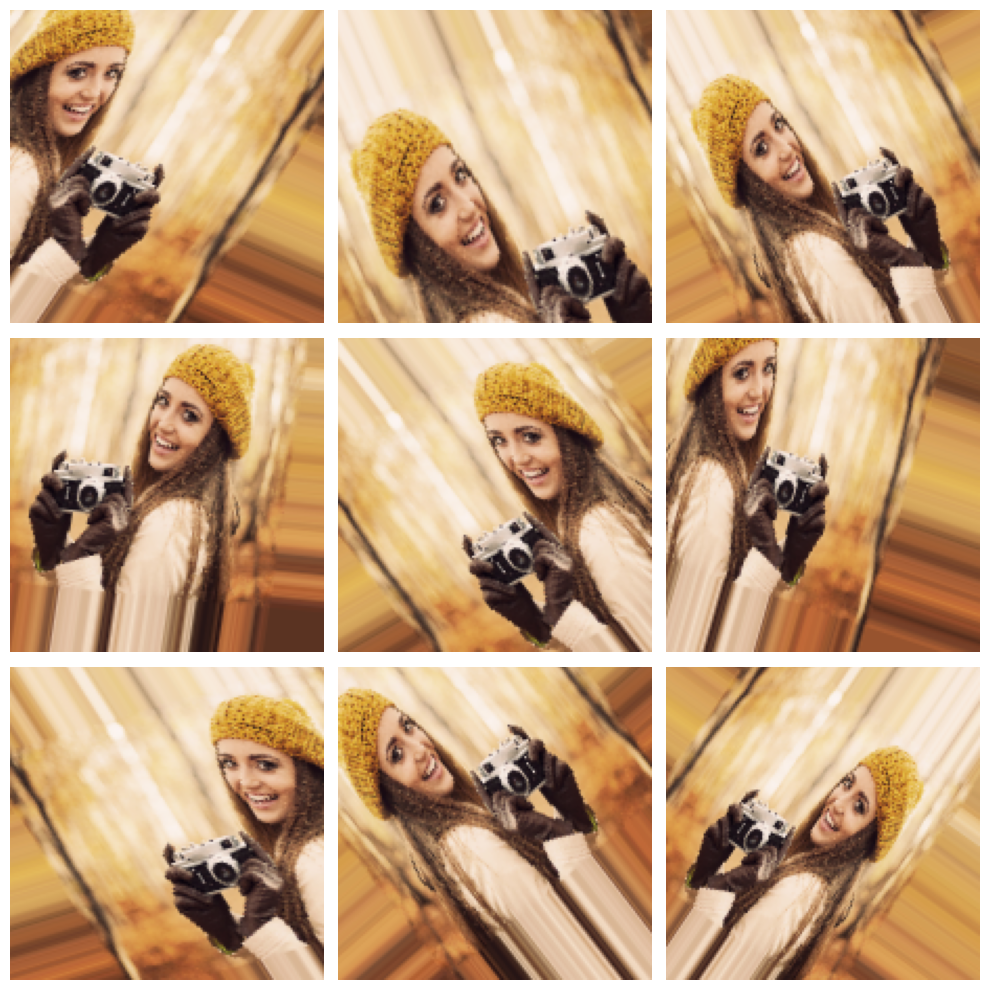

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load a sample image (replace with your own image path)
image_path = '/content/smiling.jpg'

try:
    img = load_img(image_path, target_size=(150, 150))  # Resize image
    img_array = img_to_array(img)  # Convert to NumPy array
except (FileNotFoundError, OSError):
    print(f"Warning: The image file '{image_path}' was not found or is corrupted. Creating a dummy image for demonstration purposes.")
    # Create a dummy 150x150x3 image (e.g., a simple white square on a black background)
    dummy_img_array = np.zeros((150, 150, 3), dtype=np.uint8)
    dummy_img_array[50:100, 50:100, :] = 255 # Add a white square in the middle
    img_array = dummy_img_array

img_array = img_array.reshape((1,) + img_array.shape)  # Reshape to (1, height, width, channels)

# Define ImageDataGenerator with augmentation settings
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate and plot 9 augmented images
plt.figure(figsize=(10, 10))
i = 0
for batch in datagen.flow(img_array, batch_size=1):
    plt.subplot(3, 3, i + 1)
    plt.imshow(batch[0].astype('uint8'))
    plt.axis('off')
    i += 1
    if i == 9:
        break
plt.tight_layout()
plt.savefig('augmented_images.png')
plt.show()